In [1]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI-ML/Data/FruitinAmazon.zip"
extract_path = "amazon_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ok")

ok


Classes: ['guarana', 'pupunha', 'graviola', 'tucuma', 'acai', 'cupuacu']


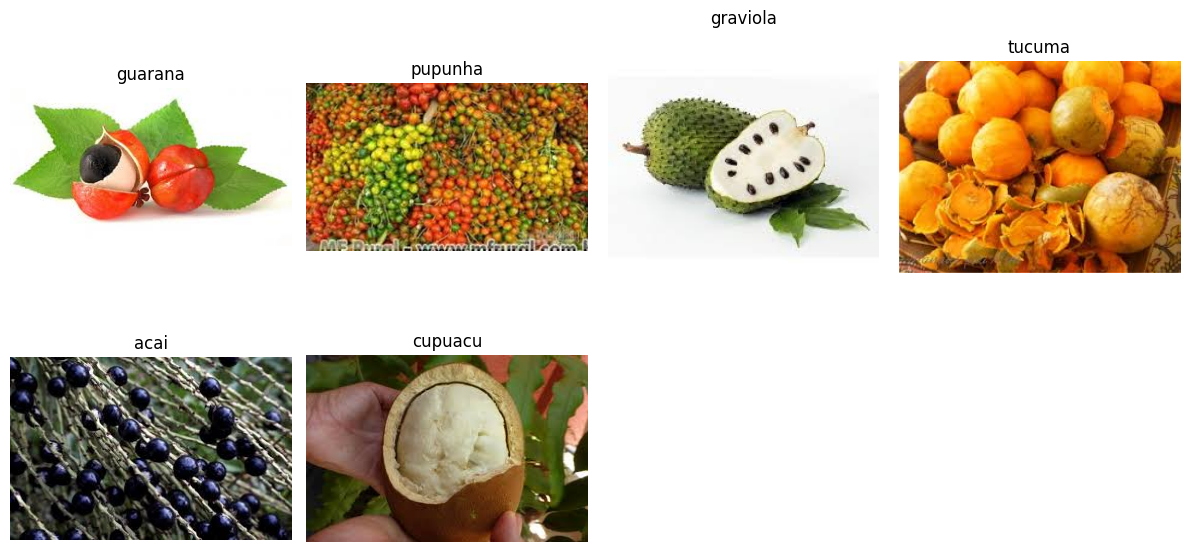

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "amazon_dataset/FruitinAmazon/train"

# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image from each class
images = []
titles = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    images.append(Image.open(img_path))
    titles.append(cls)

# Plot in grid (2 rows)
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images)//2)+1, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalize layer
rescale = tf.keras.layers.Rescaling(1./255)

# Train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [5]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.2043 - loss: 1.8953

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 606ms/step - accuracy: 0.2222 - loss: 1.9344 - val_accuracy: 0.8333 - val_loss: 1.0143
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.2361 - loss: 1.9245 - val_accuracy: 0.0000e+00 - val_loss: 1.8490
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 432ms/step - accuracy: 0.4028 - loss: 1.5164 - val_accuracy: 0.0000e+00 - val_loss: 1.8102
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 636ms/step - accuracy: 0.3889 - loss: 1.3502 - val_accuracy: 0.3889 - val_loss: 1.5411
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.6892 - loss: 1.1052

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 776ms/step - accuracy: 0.7083 - loss: 1.1193 - val_accuracy: 0.6667 - val_loss: 1.0074
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 0.6389 - loss: 0.9454 - val_accuracy: 0.5000 - val_loss: 1.2760
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6395 - loss: 0.8018

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.6528 - loss: 0.8120 - val_accuracy: 0.7222 - val_loss: 0.9448
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8657 - loss: 0.5945

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - accuracy: 0.8472 - loss: 0.5877 - val_accuracy: 0.8333 - val_loss: 0.7272
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.9317 - loss: 0.3861

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8889 - loss: 0.4493 - val_accuracy: 0.8889 - val_loss: 0.4847
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9444 - loss: 0.2917 - val_accuracy: 0.5556 - val_loss: 0.9425
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9028 - loss: 0.3103 - val_accuracy: 0.6667 - val_loss: 1.0968
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 864ms/step - accuracy: 0.9583 - loss: 0.1939 - val_accuracy: 0.8333 - val_loss: 0.5026
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.9450 - loss: 0.1618

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9444 - loss: 0.1585 - val_accuracy: 0.8889 - val_loss: 0.3082
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 1.0000 - loss: 0.0719 - val_accuracy: 0.8333 - val_loss: 0.4583
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 813ms/step - accuracy: 1.0000 - loss: 0.0568 - val_accuracy: 0.8333 - val_loss: 0.5947
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 1.0000 - loss: 0.0497

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 1.0000 - loss: 0.0427 - val_accuracy: 0.8889 - val_loss: 0.2743
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 1.0000 - loss: 0.0286

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 1.0000 - loss: 0.0303 - val_accuracy: 0.9444 - val_loss: 0.1972
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 538ms/step - accuracy: 1.0000 - loss: 0.0176 - val_accuracy: 0.8889 - val_loss: 0.2515
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 495ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.8333 - val_loss: 0.3847
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 580ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.8333 - val_loss: 0.5242
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 865ms/step - accuracy: 1.0000 - loss: 0.0061 - val_accuracy: 0.8333 - val_loss: 0.5005
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 499ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.8333 - val_loss: 0.4036
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.8889 - val_loss: 0.3119
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8889 - val_lo

In [8]:
test_dir = "amazon_dataset/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.6667 - loss: 0.8823
Test Accuracy: 0.6666666865348816


In [9]:
# Save
model.save("final_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

# Re-evaluate
loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step - accuracy: 0.6667 - loss: 0.8823


[0.8822744488716125, 0.6666666865348816]

In [10]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
              precision    recall  f1-score   support

     guarana       1.00      0.80      0.89         5
     pupunha       0.50      1.00      0.67         5
    graviola       1.00      0.60      0.75         5
      tucuma       0.56      1.00      0.71         5
        acai       1.00      0.20      0.33         5
     cupuacu       0.67      0.40      0.50         5

    accuracy                           0.67        30
   macro avg       0.79      0.67      0.64        30
weighted avg       0.79      0.67      0.64        30



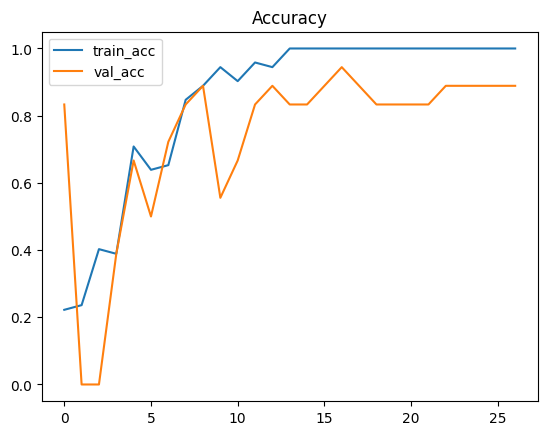

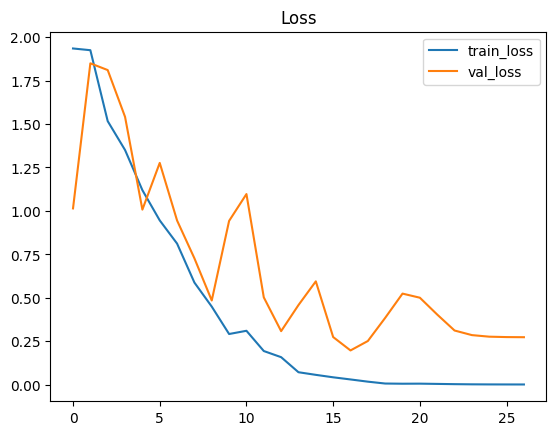

In [11]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()